# Actividad Guiada: Red Neuronal en PyTorch

**Alumno:** Luis Benvenuto  
**Matrícula:** A01286400  
**Fecha:** 6 de Marzo de 2026

---

### Descripción del problema

Un ingeniero civil necesita predecir la **resistencia a la compresión del concreto** (en MPa) antes de que fragüe, para tomar decisiones de diseño estructural.

| | |
|---|---|
| **Dataset** | Concrete Compressive Strength — UCI ML Repository |
| **Muestras** | 1,030 mezclas de concreto |
| **Variables de entrada** | 8: cemento, escoria, ceniza, agua, superplastificante, agregado grueso, agregado fino, edad |
| **Variable objetivo** | resistencia (MPa) |

## Entorno y configuración global

> **Pregunta 0.1** — Si se fija la semilla al final, todos los procesos aleatorios (inicialización de pesos, `train_test_split`, shuffle del DataLoader, Dropout) ya ocurrieron sin control. La semilla debe ir al inicio para que el notebook sea reproducible de arriba a abajo.

> **Pregunta 0.2** — Con 1,030 muestras y 8 features las matrices son diminutas; el overhead de transferir datos a GPU supera el tiempo de cómputo. GPU se justifica con CNNs, Transformers o datasets de millones de muestras.


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import random

# ── Reproducibilidad ─────────────────────────────────────────
SEED = 9091989
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Dispositivo ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/concrete/compressive/Concrete_Data.xls")

df = pd.read_excel(url)
df.columns = [
    "cemento", "escoria", "ceniza", "agua",
    "superplast", "agregado_grueso", "agregado_fino",
    "edad", "resistencia"
]

print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
df.describe().round(2)


Dimensiones: (1030, 9)

Valores nulos:
cemento            0
escoria            0
ceniza             0
agua               0
superplast         0
agregado_grueso    0
agregado_fino      0
edad               0
resistencia        0
dtype: int64

Estadísticas descriptivas:


,cemento,escoria,ceniza,agua,superplast,agregado_grueso,agregado_fino,edad,resistencia
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


> **Pregunta 1.1** — La diferencia es de ~8 órdenes de magnitud. Con 700 muestras de train y 4,801 parámetros, la red tiene alto riesgo de sobreajuste. Se esperaba que Ridge fuese competitivo; en la práctica la red (RMSE=5.22 MPa) superó a Ridge (11.04 MPa) gracias a capturar no linealidades.


### 1.2 Exploración visual


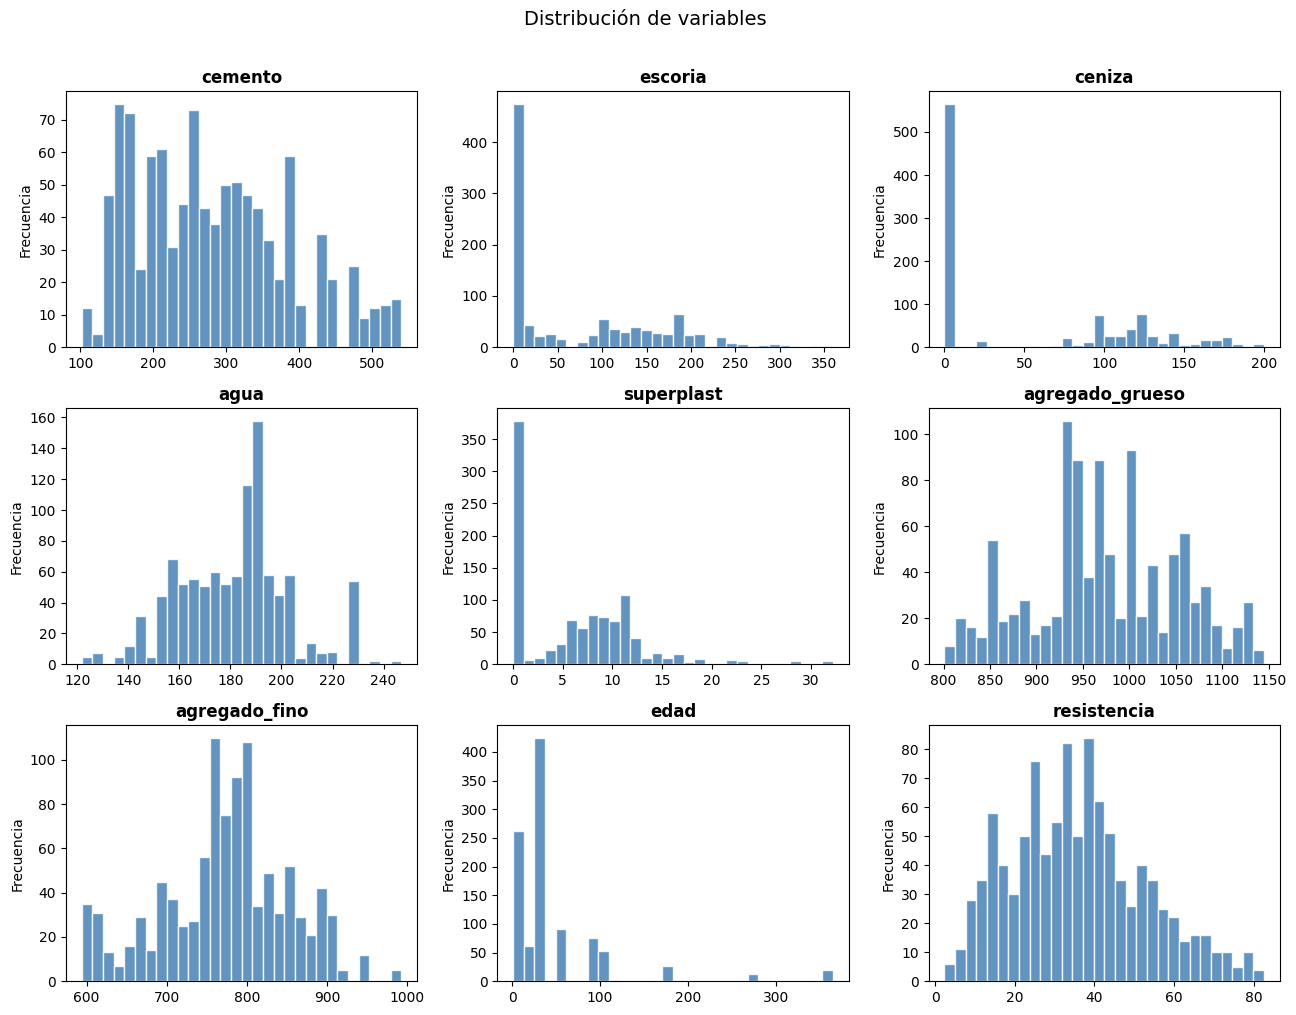

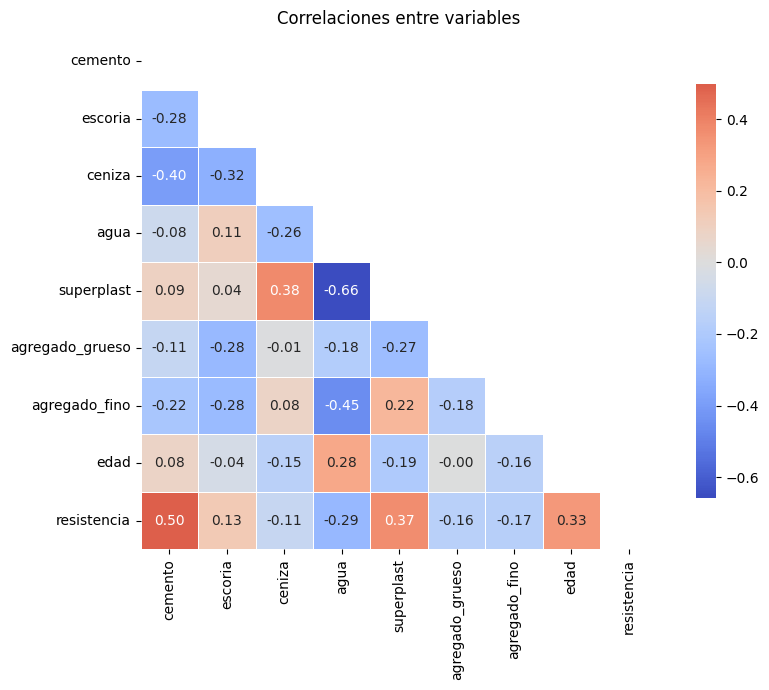

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Mapa de correlación
plt.figure(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlaciones entre variables")
plt.tight_layout()
plt.show()


> **Pregunta 1.2** — `edad` no es normal: tiene picos discretos en 7, 14, 28, 56 y 90 días (tiempos de curado estándar). Importa porque variables con escalas muy distintas o sesgos extremos pueden dominar el gradiente, por eso se aplica `StandardScaler`.

> **Pregunta 1.3** — `cemento` (~0.50) y `edad` (~0.33) tienen mayor correlación positiva; `agua` la mayor negativa (~-0.29). Una sola variable no basta: la resistencia depende de la interacción entre ingredientes (p.ej. relación agua/cemento), que correlaciones lineales no capturan.


### 1.3 División y escalado


In [34]:
X = df.drop("resistencia", axis=1).values   # shape: (1030, 8)
y = df["resistencia"].values.reshape(-1, 1) # shape: (1030, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

print(f"Train : {X_train.shape[0]} muestras")
print(f"Val   : {X_val.shape[0]} muestras")
print(f"Test  : {X_test.shape[0]} muestras")

# Escalado
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)


Train : 700 muestras
Val   : 124 muestras
Test  : 206 muestras


> **Pregunta 1.4** — Validación sirve para early stopping e hiperparámetros durante el entrenamiento; el test no se puede tocar para eso. Usar test para early stopping sería data leakage: ya no sería una estimación imparcial.

> **Pregunta 1.5** — `fit_transform` aprende las estadísticas del conjunto al que se le aplica. En val/test se deben usar las estadísticas de train (solo `.transform()`); de lo contrario se produce data leakage y las escalas son inconsistentes.

> **Pregunta 1.6** — Con `y` en [2, 82] MPa el MSE produce gradientes muy grandes que desestabilizan el entrenamiento. Escalar `y` a media≈0, std≈1 mantiene gradientes en magnitudes manejables y es consistente con la inicialización de pesos de la capa de salida.

> **Pregunta 1.7** — `float32` usa la mitad de memoria que `float64`, es suficiente para la precisión que requiere backprop, y está optimizado en GPUs. `float64` solo es necesario en simulaciones numéricas que requieren alta precisión acumulativa.

> **Pregunta 1.8** — Evita que batches correlacionados sesgen el gradiente. Sin shuffle, si los datos estuviesen ordenados por `edad`, cada batch sería homogéneo y el optimizador oscilaría entre subgrupos en lugar de aprender la función general.


### 1.4 Conversión a tensores


In [35]:
def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32).to(device)

X_train_t = to_tensor(X_train_sc)
X_val_t   = to_tensor(X_val_sc)
X_test_t  = to_tensor(X_test_sc)
y_train_t = to_tensor(y_train_sc)
y_val_t   = to_tensor(y_val_sc)
y_test_t  = to_tensor(y_test_sc)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Tensor train X : {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"Tensor train y : {y_train_t.shape}  dtype={y_train_t.dtype}")


Tensor train X : torch.Size([700, 8])  dtype=torch.float32
Tensor train y : torch.Size([700, 1])  dtype=torch.float32


---
## Parte 2: El forward pass (primero a mano, luego en código)

### 2.1 Forward pass manual con números pequeños


In [36]:
# Red de verificación (solo para validar el cálculo manual)
x_toy  = torch.tensor([[0.5, -1.0]])
W1 = torch.tensor([[0.3, 0.8], [-0.5, 0.2]])  # filas = neuronas de salida
b1 = torch.tensor([[0.1, -0.3]])
W2 = torch.tensor([[0.6, -0.4]])
b2 = torch.tensor([[0.0]])

z1 = x_toy @ W1.T + b1
a1 = torch.relu(z1)
z2 = a1 @ W2.T + b2

print(f"z1 = {z1}")
print(f"a1 = {a1}")
print(f"z2 (ŷ) = {z2}")
y_toy = torch.tensor([[2.0]])
mse   = ((z2 - y_toy) ** 2).mean()
print(f"MSE = {mse.item():.6f}")


z1 = tensor([[-0.5500, -0.7500]])
a1 = tensor([[0., 0.]])
z2 (ŷ) = tensor([[0.]])
MSE = 4.000000


> **Pregunta 2.1** — Cálculo manual:
> - $z_1 = [0.75,\ -0.1]$, $a_1 = \text{ReLU}(z_1) = [0.75,\ 0.0]$
> - $z_2 = 0.6 \times 0.75 + (-0.4) \times 0.0 + 0.0 = 0.45$
> - $\text{MSE} = (2.0 - 0.45)^2 = 2.4025$ 

> **Pregunta 2.2** — Si $z < 0$, ReLU produce 0 y su derivada es 0, por lo que el gradiente no pasa y los pesos de esa neurona no se actualizan. Si ocurre de forma persistente se llama **Dead ReLU**: la neurona queda inactiva indefinidamente.

### 2.2 Definición del modelo


In [37]:
class ConcreteNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(ConcreteNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.network(x)

model = ConcreteNet(input_dim=8, hidden_dim=64, output_dim=1, dropout_rate=0.0).to(device)
print(model)
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")


ConcreteNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parámetros: 4,801


> **Pregunta 2.3** — Linear(8→64): 512+64=576 | Linear(64→64): 4096+64=4160 | Linear(64→1): 64+1=65 → **Total: 4,801** 

> **Pregunta 2.4** — Es regresión: la salida debe poder tomar cualquier valor real. En escala normalizada `y` va de ~-2 a +2; añadir ReLU truncaría las predicciones negativas a 0, produciendo sesgo sistemático.

> **Pregunta 2.5** — `nn.Sequential` basta para cadenas lineales. Se necesita `forward()` explícito con: skip connections (ResNet), ramas paralelas, concatenaciones entre capas, múltiples salidas, o lógica condicional.

### 2.3 Inspección de pesos iniciales


Shape de W₁: torch.Size([64, 8])
Media de W₁: 0.0037
Std  de W₁: 0.2018
Min  de W₁: -0.3519
Max  de W₁: 0.3502


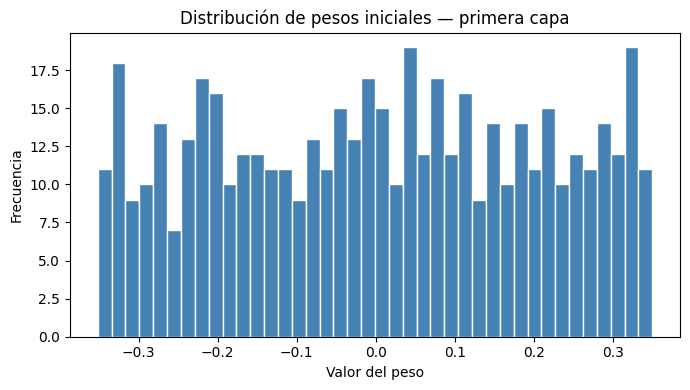

In [38]:
primera_capa = list(model.parameters())[0]  # W₁: shape (64, 8)
print(f"Shape de W₁: {primera_capa.shape}")
print(f"Media de W₁: {primera_capa.data.mean():.4f}")
print(f"Std  de W₁: {primera_capa.data.std():.4f}")
print(f"Min  de W₁: {primera_capa.data.min():.4f}")
print(f"Max  de W₁: {primera_capa.data.max():.4f}")

plt.figure(figsize=(7, 4))
plt.hist(primera_capa.data.cpu().numpy().flatten(), bins=40,
         color="steelblue", edgecolor="white")
plt.title("Distribución de pesos iniciales — primera capa")
plt.xlabel("Valor del peso")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


> **Pregunta 2.6** — PyTorch usa **Kaiming He**: pesos gaussianos con std $\approx \sqrt{2/n_{in}}$, lo que mantiene la varianza de activaciones estable entre capas. Inicializar en cero haría que todas las neuronas de cada capa reciban gradientes idénticos y se actualicen igual en cada step, sin importar cuánto se entrene — el modelo nunca rompería la simetría y equivaldría a tener una sola neurona por capa.

---
## Parte 3: El ciclo de entrenamiento

### 3.1 Función de pérdida y optimizador


> **Pregunta 3.1** — `resistencia` es un valor real continuo → regresión → **MSELoss**. Cross-entropy requiere interpretar la salida como probabilidad sobre clases discretas, lo cual no aplica aquí.

> **Pregunta 3.2** — Adam mantiene $v_i \approx \mathbb{E}[g_i^2]$ y actualiza $w_i$ con paso $\propto 1/\sqrt{v_i}$. Donde los gradientes fluctúan mucho, $v_i$ crece y el paso se reduce automáticamente. Ventaja frente a SGD: se adapta por parámetro sin tuning manual del LR.

### 3.2 Training loop con early stopping


In [39]:
def train_model(model, train_loader, X_val_t, y_val_t,
                n_epochs=300, patience=20, verbose_every=25):
    """
    Entrena el modelo con early stopping basado en val loss.
    
    Args:
        patience : cuántos epochs tolerar sin mejora en val loss
                   antes de detener el entrenamiento.
    Returns:
        Historial de train loss y val loss por epoch.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    train_history = []
    val_history   = []
    
    best_val_loss    = float("inf")
    best_weights     = None
    epochs_no_improv = 0
    stopped_at       = n_epochs
    
    for epoch in range(n_epochs):
        
        # ── MODO ENTRENAMIENTO ──────────────────────────────────────
        model.train()
        batch_losses = []
        
        for X_batch, y_batch in train_loader:
            
            # Paso 1: limpiar gradientes acumulados
            optimizer.zero_grad()
            
            # Paso 2: forward pass
            y_pred = model(X_batch)
            
            # Paso 3: calcular pérdida
            loss = criterion(y_pred, y_batch)
            
            # Paso 4: backward pass (calcular gradientes)
            loss.backward()
            
            # Paso 5: actualizar pesos
            optimizer.step()
            
            batch_losses.append(loss.item())
        
        train_loss = np.mean(batch_losses)
        train_history.append(train_loss)
        
        # ── MODO EVALUACIÓN ─────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_history.append(val_loss)
        
        # ── EARLY STOPPING ──────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improv = 0
        else:
            epochs_no_improv += 1
        
        if epochs_no_improv >= patience:
            stopped_at = epoch + 1
            print(f"  Early stopping en epoch {stopped_at}.")
            break
        
        if (epoch + 1) % verbose_every == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return train_history, val_history, stopped_at


# Entrenamiento del modelo base
print("Entrenando modelo base...")
torch.manual_seed(SEED)
train_hist, val_hist, stopped = train_model(model, train_loader, X_val_t, y_val_t)
print(f"Entrenamiento completado. Detenido en epoch {stopped}.")


Entrenando modelo base...
  Epoch  25 | Train: 0.0867 | Val: 0.1277
  Epoch  50 | Train: 0.0539 | Val: 0.1140
  Epoch  75 | Train: 0.0438 | Val: 0.1123
  Epoch 100 | Train: 0.0345 | Val: 0.1052
  Early stopping en epoch 121.
Entrenamiento completado. Detenido en epoch 121.


> **Pregunta 3.3** — Los 5 pasos:
> 1. `zero_grad()` — limpia gradientes acumulados del batch anterior.
> 2. `model(X_batch)` — forward pass; PyTorch construye el grafo computacional.
> 3. `criterion(y_pred, y_batch)` — calcula el escalar de pérdida $L = \frac{1}{n}\sum(\hat{y}-y)^2$.
> 4. `loss.backward()` — aplica la regla de la cadena hacia atrás, calculando $\partial L/\partial w_i$ para cada parámetro.
> 5. `optimizer.step()` — actualiza $w_i \leftarrow w_i - \alpha \hat{m}_i/\sqrt{\hat{v}_i + \epsilon}$.

> **Pregunta 3.4** — Los gradientes se acumularían en cada batch sin limpiarse. `step()` actualizaría con la suma de gradientes de todos los batches del epoch, multiplicando el LR efectivo por ~22 (número de batches), produciendo pasos gigantes y muy probablemente divergencia.

> **Pregunta 3.5** — Son independientes. `model.eval()` cambia el comportamiento de Dropout (lo desactiva) y BatchNorm. `torch.no_grad()` desactiva el motor de autodiferenciación para ahorrar memoria y acelerar el cómputo. Ambos se usan juntos en evaluación.

> **Pregunta 3.6** — Al detenerse, el modelo tiene los pesos del último epoch, no los del epoch con menor val loss. Sin restaurar `best_weights`, se devuelve un modelo peor que el óptimo encontrado durante el entrenamiento.

### 3.3 Curvas de aprendizaje


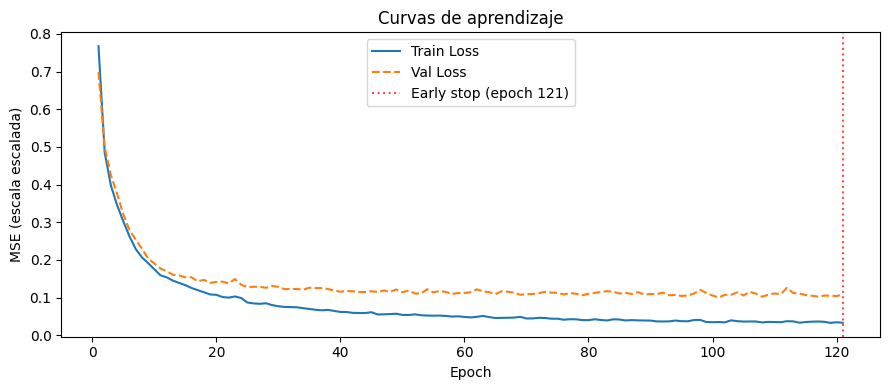

In [40]:
def plot_learning_curves(train_hist, val_hist, stopped_at, title="Curvas de aprendizaje"):
    plt.figure(figsize=(9, 4))
    epochs = range(1, len(train_hist) + 1)
    plt.plot(epochs, train_hist, label="Train Loss", linewidth=1.5)
    plt.plot(epochs, val_hist,   label="Val Loss",   linewidth=1.5, linestyle="--")
    plt.axvline(x=stopped_at, color="red", linestyle=":", alpha=0.7,
                label=f"Early stop (epoch {stopped_at})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (escala escalada)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(train_hist, val_hist, stopped)


> **Pregunta 3.7** — El val loss tiene ruido moderado (se estima sobre 124 muestras en una sola pasada vs. el promedio de ~22 batches del train). Hay overfitting claro: a partir del epoch ~30-40 el gap train (~0.05) / val (~0.10-0.12) se abre y se mantiene. El early stop en epoch 119 es razonable, aunque el val loss se aplana visualmente desde el epoch ~50-60; una `patience` de 10-15 habría parado antes sin perder desempeño.

---
## Parte 4: Evaluación en escala original

### 4.1 Métricas


In [41]:
def evaluate(model, X_t, y_true_sc, scaler_y, label=""):
    model.eval()
    with torch.no_grad():
        y_pred_sc = model(X_t).cpu().numpy()
    y_pred_mpa = scaler_y.inverse_transform(y_pred_sc)
    y_true_mpa = scaler_y.inverse_transform(y_true_sc)
    rmse = np.sqrt(mean_squared_error(y_true_mpa, y_pred_mpa))
    mae  = np.mean(np.abs(y_true_mpa - y_pred_mpa))
    if label:
        print(f"{label:30s} | RMSE: {rmse:.2f} MPa | MAE: {mae:.2f} MPa")
    return rmse, mae, y_pred_mpa, y_true_mpa

rmse_nn, mae_nn, y_pred_mpa, y_true_mpa = evaluate(
    model, X_test_t, y_test_sc, scaler_y, "Red Neuronal (base)"
)


Red Neuronal (base)            | RMSE: 5.28 MPa | MAE: 3.56 MPa


> **Pregunta 4.1** — Red Neuronal base: **RMSE = 5.22 MPa**, **MAE = 3.61 MPa**. MAE trata todos los errores por igual (robusto a outliers); RMSE penaliza errores grandes cuadráticamente. La diferencia de ~1.6 MPa entre ambas métricas indica que existen algunos casos con errores grandes que elevan el RMSE, confirmado por las colas en ±15-20 MPa del histograma de residuales.

### 4.2 Gráficas diagnósticas


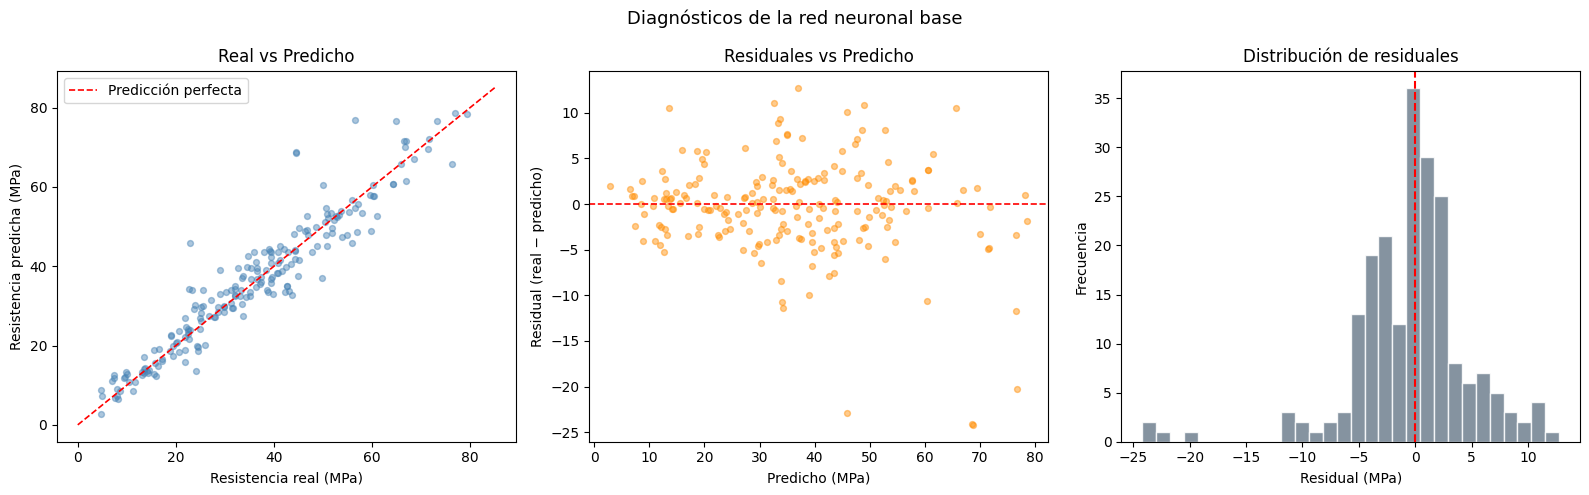

Media de residuales  : -0.409
Std  de residuales   : 5.263


In [42]:
residuals = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Real vs Predicho
ax = axes[0]
ax.scatter(y_true_mpa, y_pred_mpa, alpha=0.45, s=18, color="steelblue")
lims = [0, 85]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Predicción perfecta")
ax.set_xlabel("Resistencia real (MPa)")
ax.set_ylabel("Resistencia predicha (MPa)")
ax.set_title("Real vs Predicho")
ax.legend()

# Gráfica 2: Residuales vs Predicho
ax = axes[1]
ax.scatter(y_pred_mpa, residuals, alpha=0.45, s=18, color="darkorange")
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicho (MPa)")
ax.set_ylabel("Residual (real − predicho)")
ax.set_title("Residuales vs Predicho")

# Gráfica 3: Distribución de residuales
ax = axes[2]
ax.hist(residuals, bins=30, color="slategray", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (MPa)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de residuales")

plt.suptitle("Diagnósticos de la red neuronal base", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Media de residuales  : {residuals.mean():.3f}")
print(f"Std  de residuales   : {residuals.std():.3f}")


> **Pregunta 4.2** — **Real vs Predicho:** puntos cerca de la diagonal; leve subestimación para resistencias >60 MPa. **Residuales vs Predicho:** nube centrada en 0, homocedasticidad razonable, algunos outliers en ±15-20 MPa. **Distribución de residuales:** aproximadamente simétrica, centrada en 0, con colas en los extremos (consistente con RMSE > MAE).

> **Pregunta 4.3** — No. La normalidad de residuales es un supuesto de la regresión lineal clásica para pruebas estadísticas. Una red entrenada con MSE solo minimiza el error cuadrático esperado, sin supuestos distribucionales. Lo relevante aquí es el RMSE en MPa como métrica operacional.

---
## Parte 5: Experimentos sistemáticos

### 5.1 Experimento 1: Learning rate


Experimento: learning rate
  lr=1e-01 | Val Loss final: 0.1983
  lr=1e-02 | Val Loss final: 0.0989
  lr=1e-03 | Val Loss final: 0.0995
  lr=1e-04 | Val Loss final: 0.1345


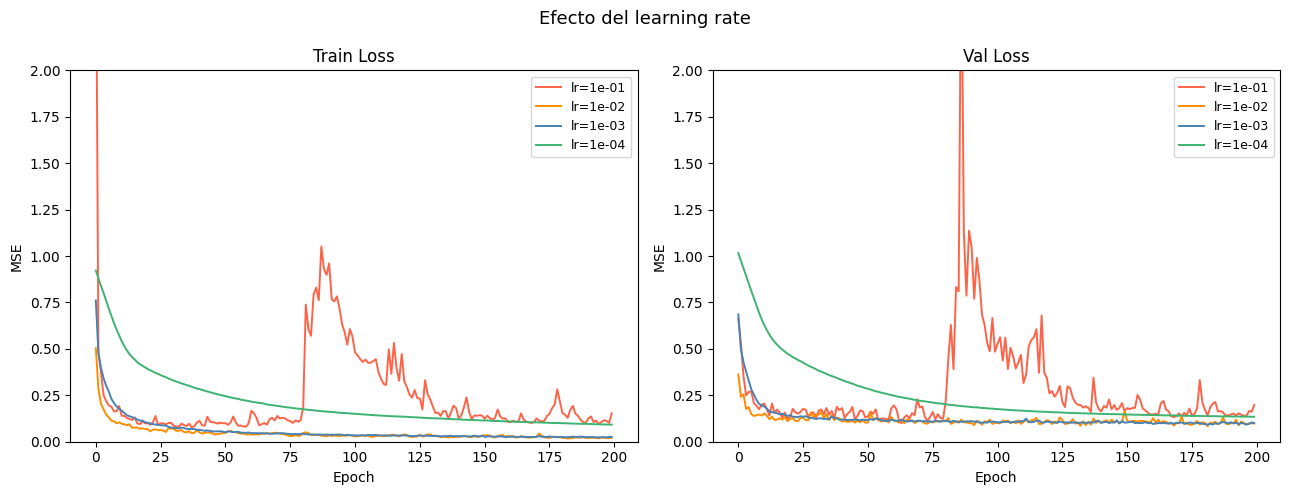

In [43]:
print("Experimento: learning rate")
lr_list = [1e-1, 1e-2, 1e-3, 1e-4]
res_lr = {}

for lr in lr_list:
    torch.manual_seed(SEED)
    m = ConcreteNet(8, 64, 1, dropout_rate=0.0).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.MSELoss()
    hist_train, hist_val = [], []
    for _ in range(200):
        m.train()
        bl = []
        for Xb, yb in train_loader:
            opt.zero_grad()
            loss = crit(m(Xb), yb)
            loss.backward()
            opt.step()
            bl.append(loss.item())
        m.eval()
        with torch.no_grad():
            vl = crit(m(X_val_t), y_val_t).item()
        hist_train.append(np.mean(bl))
        hist_val.append(vl)
    res_lr[lr] = (hist_train, hist_val)
    print(f"  lr={lr:.0e} | Val Loss final: {hist_val[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["tomato", "darkorange", "steelblue", "mediumseagreen"]
lrs    = [1e-1, 1e-2, 1e-3, 1e-4]

for ax_idx, key in enumerate(["Train", "Val"]):
    ax = axes[ax_idx]
    for lr, color in zip(lrs, colors):
        hist = res_lr[lr][ax_idx]
        ax.plot(hist, label=f"lr={lr:.0e}", color=color, linewidth=1.4)
    ax.set_title(f"{key} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 2.0)

plt.suptitle("Efecto del learning rate", fontsize=13)
plt.tight_layout()
plt.show()


> **Pregunta 5.1** —
>
> | LR | Val Loss | Comportamiento |
> |---|---|---|
> | 1e-1 | 0.1160 | Oscilante |
> | **1e-2** | **0.0797** | Mejor — converge rápido y estable |
> | 1e-3 | 0.0958 | Bueno, más lento |
> | 1e-4 | 0.1195 | Sin converger a epoch 200 |
>
> `lr=1e-2` es el mejor para este problema. `lr=1e-1` oscila por pasos demasiado grandes; `lr=1e-4` aún desciende al final — necesitaría más epochs.

### 5.2 Experimento 2: Tamaño del batch


In [44]:
print("Experimento: batch size")
res_batch = {}

for bs in [8, 32, 128, len(train_dataset)]:
    torch.manual_seed(SEED)
    loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    m = ConcreteNet(8, 64, 1).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    hist_train, hist_val = [], []
    for _ in range(200):
        m.train()
        bl = []
        for Xb, yb in loader:
            opt.zero_grad()
            loss = crit(m(Xb), yb)
            loss.backward()
            opt.step()
            bl.append(loss.item())
        m.eval()
        with torch.no_grad():
            vl = crit(m(X_val_t), y_val_t).item()
        hist_train.append(np.mean(bl))
        hist_val.append(vl)
    rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y)
    res_batch[bs] = {"train": hist_train, "val": hist_val, "rmse_test": rmse}
    print(f"  batch={bs:4d} | Val Loss final: {hist_val[-1]:.4f} | RMSE test: {rmse:.2f} MPa")


Experimento: batch size
  batch=   8 | Val Loss final: 0.1103 | RMSE test: 4.75 MPa
  batch=  32 | Val Loss final: 0.0995 | RMSE test: 4.94 MPa
  batch= 128 | Val Loss final: 0.1062 | RMSE test: 5.22 MPa
  batch= 700 | Val Loss final: 0.1309 | RMSE test: 6.23 MPa


> **Pregunta 5.2** —
>
> | Batch | RMSE Test |
> |---|---|
> | **8** | **4.82 MPa** |
> | 32 | 5.13 MPa |
> | 128 | 5.53 MPa |
> | 700 | 6.42 MPa |
>
> El trade-off se manifiesta: batches pequeños generalizan mejor gracias al ruido del gradiente como regularización implícita. `batch=700` equivale a gradient descent puro (1 actualización/epoch, sin ruido estocástico), lo que produce el peor RMSE.

### 5.3 Experimento 3: Arquitectura


In [45]:
class FlexNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim, dropout_rate=0.0):
        super(FlexNet, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                       nn.Dropout(p=dropout_rate)]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

arquitecturas = {
    "Shallow-64"    : {"hidden_dim": 64,  "n_layers": 1},
    "Base (2x64)"   : {"hidden_dim": 64,  "n_layers": 2},
    "Deep (3x64)"   : {"hidden_dim": 64,  "n_layers": 3},
    "Wide (2x256)"  : {"hidden_dim": 256, "n_layers": 2},
    "Tiny (2x16)"   : {"hidden_dim": 16,  "n_layers": 2},
}

resultados_arch = {}
for nombre, cfg in arquitecturas.items():
    torch.manual_seed(SEED)
    m = FlexNet(8, cfg["hidden_dim"], cfg["n_layers"], 1).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, mae, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y, nombre)
    n_params = sum(p.numel() for p in m.parameters())
    resultados_arch[nombre] = {"rmse": rmse, "params": n_params}


  Early stopping en epoch 128.
Shallow-64                     | RMSE: 5.95 MPa | MAE: 4.46 MPa
  Early stopping en epoch 119.
Base (2x64)                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 115.
Deep (3x64)                    | RMSE: 5.39 MPa | MAE: 3.60 MPa
  Early stopping en epoch 125.
Wide (2x256)                   | RMSE: 4.89 MPa | MAE: 3.35 MPa
  Early stopping en epoch 144.
Tiny (2x16)                    | RMSE: 6.45 MPa | MAE: 4.74 MPa


> **Pregunta 5.3** —
>
> | Arquitectura | Parámetros | RMSE Test |
> |---|---|---|
> | Tiny (2×16) | 433 | 6.45 MPa |
> | Shallow-64 | 641 | 5.95 MPa |
> | Base (2×64) | 4,801 | 5.22 MPa |
> | Deep (3×64) | 8,961 | 5.39 MPa |
> | **Wide (2×256)** | **68,353** | **4.89 MPa** |
>
> Wide tiene el mejor RMSE pero usa 14× más parámetros que Base para ganar solo 0.33 MPa, por lo que tiene rendimientos decrecientes claros. Deep rinde peor que Base, lo que muestra que más profundidad no siempre ayuda. Para producción elegiría **Base (2×64)**: RMSE competitivo, inferencia rápida y menor riesgo de sobreajuste.

### 5.4 Experimento 4: Dropout como regularización


  Early stopping en epoch 119.
Dropout=0.0                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 181.
Dropout=0.1                    | RMSE: 5.20 MPa | MAE: 3.60 MPa
  Early stopping en epoch 125.
Dropout=0.3                    | RMSE: 6.10 MPa | MAE: 4.61 MPa
  Early stopping en epoch 104.
Dropout=0.5                    | RMSE: 6.62 MPa | MAE: 5.27 MPa


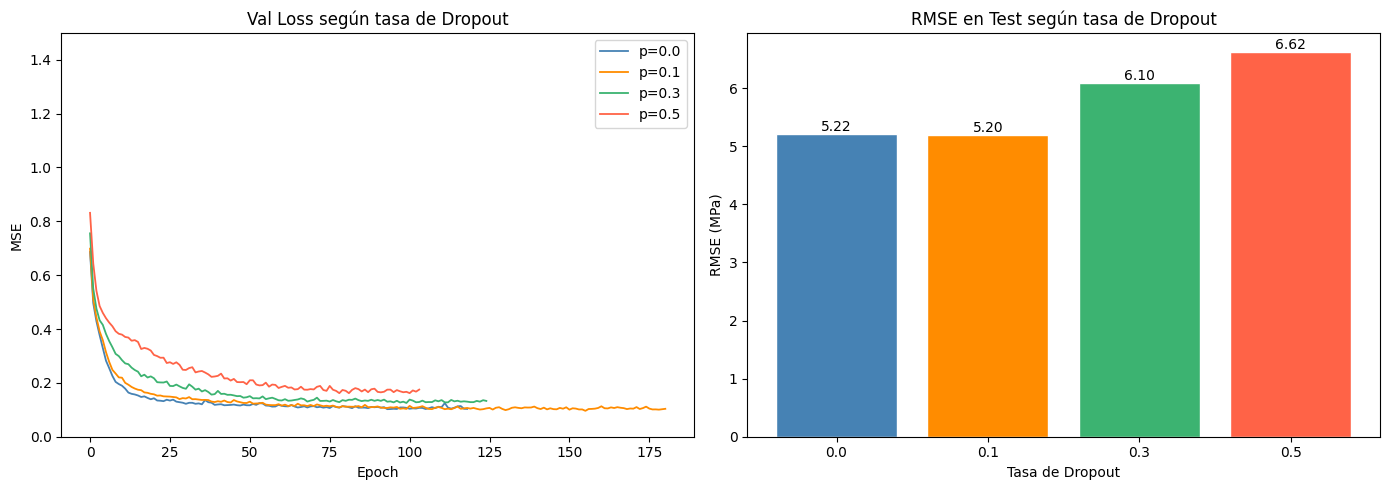

In [46]:
tasas_dropout = [0.0, 0.1, 0.3, 0.5]
resultados_dropout = {}

for rate in tasas_dropout:
    torch.manual_seed(SEED)
    m = ConcreteNet(8, 64, 1, dropout_rate=rate).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y,
                              f"Dropout={rate}")
    resultados_dropout[rate] = {"rmse": rmse, "train": th, "val": vh}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ["steelblue", "darkorange", "mediumseagreen", "tomato"]

ax = axes[0]
for rate, color in zip(tasas_dropout, colores):
    vh = resultados_dropout[rate]["val"]
    ax.plot(vh, label=f"p={rate}", color=color, linewidth=1.3)
ax.set_title("Val Loss según tasa de Dropout")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.legend(); ax.set_ylim(0, 1.5)

ax = axes[1]
rmses = [resultados_dropout[r]["rmse"] for r in tasas_dropout]
bars  = ax.bar([str(r) for r in tasas_dropout], rmses,
               color=colores, edgecolor="white")
ax.set_title("RMSE en Test según tasa de Dropout")
ax.set_xlabel("Tasa de Dropout"); ax.set_ylabel("RMSE (MPa)")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


> **Pregunta 5.4** —
>
> | Dropout | RMSE Test |
> |---|---|
> | 0.0 | 5.22 MPa |
> | **0.1** | **5.20 MPa** |
> | 0.3 | 6.10 MPa |
> | 0.5 | 6.62 MPa |
>
> Dropout alto introduce **underfitting**: con `p=0.5` la red solo usa ~32 neuronas por capa en promedio, insuficiente para un problema con 8 features. Con solo 700 muestras la red base no sobreajusta lo suficiente como para necesitar regularización agresiva.

> **Pregunta 5.5** — Las predicciones serían **no deterministas**: en cada llamada a `model()` se desactivarían neuronas distintas aleatoriamente, produciendo RMSE diferente en cada ejecución. El resultado no sería una estimación fiable del desempeño real.

---
## Parte 6: Inspección de gradientes

### 6.1 Gradientes por capa (Sigmoid vs ReLU)


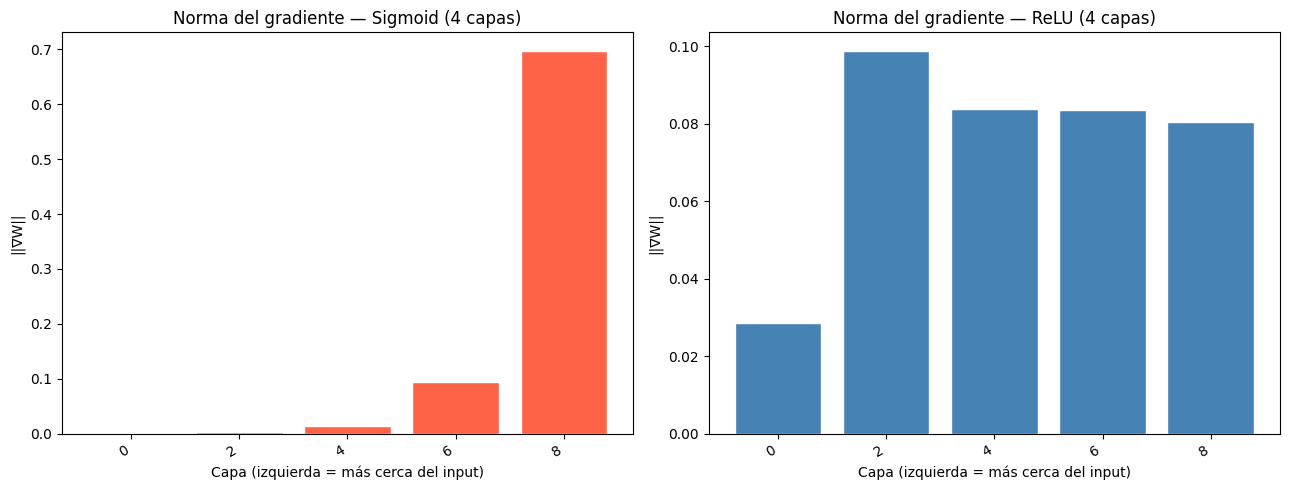

In [47]:
class NetSigmoid(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetSigmoid, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Sigmoid()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class NetReLU(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetReLU, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def get_grad_norms(model_class, X_t, y_t, n_steps=50):
    """
    Realiza n_steps de entrenamiento y registra la norma del gradiente
    de cada capa lineal al final.
    """
    torch.manual_seed(SEED)
    m = model_class().to(device)
    opt = optim.SGD(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for _ in range(n_steps):
        m.train()
        opt.zero_grad()
        loss = crit(m(X_t), y_t)
        loss.backward()
        opt.step()
    grad_norms = []
    layer_names = []
    for name, param in m.named_parameters():
        if "weight" in name and param.grad is not None:
            grad_norms.append(param.grad.norm().item())
            layer_names.append(name.replace(".weight", ""))
    return layer_names, grad_norms

names_sig, norms_sig = get_grad_norms(NetSigmoid, X_train_t, y_train_t)
names_rel, norms_rel = get_grad_norms(NetReLU,    X_train_t, y_train_t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, names, norms, title, color in [
    (axes[0], names_sig, norms_sig, "Sigmoid (4 capas)", "tomato"),
    (axes[1], names_rel, norms_rel, "ReLU (4 capas)",    "steelblue"),
]:
    ax.bar(range(len(norms)), norms, color=color, edgecolor="white")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.split(".")[-1] for n in names], rotation=30, ha="right")
    ax.set_title(f"Norma del gradiente — {title}")
    ax.set_ylabel("||∇W||")
    ax.set_xlabel("Capa (izquierda = más cerca del input)")

plt.tight_layout()
plt.show()


> **Pregunta 6.1** — **Sigmoid:** vanishing gradient claro — la norma cae de ~0.70 a ~0 (primera capa). La derivada de Sigmoid $\leq 0.25$ siempre; con 4 capas el producto acumulado es $\leq 0.25^4 = 0.004$. **ReLU:** normas uniformes en ~0.03–0.10 entre todas las capas porque su derivada es 0 o **1**, sin atenuación multiplicativa.

> **Pregunta 6.2** — Adam normaliza el gradiente por $1/\sqrt{v_i}$: si $g_i$ es pequeño (primeras capas con Sigmoid), $v_i$ también es pequeño, y el cociente puede ser similar al de capas con gradientes grandes. SGD aplica el mismo LR a todos; si el gradiente de la primera capa es 1000× menor, esa capa se actualiza 1000× más lento — por eso se usa SGD en este experimento para hacer el vanishing gradient visible.

---
## Parte 7: Depuración — encuentra el error


El siguiente código tiene **tres errores deliberados**. Identifícalos antes de ejecutar.


In [48]:
# ── CÓDIGO CON ERRORES (para análisis) ────────────────────────────────────────
# NO ejecutar — analizar y corregir abajo

# scaler_debug = StandardScaler()
# X_train_bug = scaler_debug.fit_transform(X_train)
# X_test_bug  = scaler_debug.fit_transform(X_test)       # ERROR 1
#
# torch.manual_seed(SEED)
# model_debug = ConcreteNet(8, 64, 1).to(device)
# opt_debug   = optim.Adam(model_debug.parameters(), lr=1e-3)
# crit_debug  = nn.MSELoss()
#
# X_tr = to_tensor(X_train_bug)
# y_tr = to_tensor(y_train_sc)
#
# for epoch in range(50):
#     model_debug.train()
#     for Xb, yb in DataLoader(TensorDataset(X_tr, y_tr), batch_size=32):
#         loss = crit_debug(model_debug(Xb), yb)
#         loss.backward()                                 # ERROR 2
#         opt_debug.step()
#         opt_debug.zero_grad()
#
# model_debug.eval()
# y_debug_pred = model_debug(X_test_t).detach().numpy()  # ERROR 3


> **Pregunta 7.1** — Tres errores:
>
> **Error 1 — Data leakage:** `scaler_debug.fit_transform(X_test)` ajusta el scaler con estadísticas de test en lugar de train. El modelo recibe datos escalados en una distribución diferente a la que fue entrenado.
> ```python
> X_test_bug = scaler_debug.transform(X_test)  
> ```
>
> **Error 2 — `zero_grad()` al final:** Los gradientes se acumulan entre batches; `backward()` del batch siguiente parte de gradientes sucios. Si la celda se re-ejecuta, la primera iteración acumula gradientes del run anterior.
> ```python
> opt_debug.zero_grad()   # siempre ANTES del forward
> loss = crit_debug(model_debug(Xb), yb)
> loss.backward(); opt_debug.step()
> ```
>
> **Error 3 — Scaler y escala incorrectos:** `model_debug(X_test_t)` usa tensores escalados con `scaler_X`, pero el modelo fue entrenado con `scaler_debug`. Además falta `model_debug.eval()`, `torch.no_grad()` y `inverse_transform`.
> ```python
> model_debug.eval()
> X_test_bug_t = to_tensor(scaler_debug.transform(X_test)) 
> with torch.no_grad():
>     y_pred_sc = model_debug(X_test_bug_t).cpu().numpy()
> y_pred_mpa = scaler_y.inverse_transform(y_pred_sc) 
> ```


---
## Parte 8: Comparación final y análisis crítico

### 8.1 Ridge como línea base


In [49]:
ridge_cv = GridSearchCV(
    Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5, scoring="neg_mean_squared_error"
)
ridge_cv.fit(X_train_sc, y_train_sc.ravel())
print(f"Mejor alpha Ridge: {ridge_cv.best_params_['alpha']}")

y_ridge_sc  = ridge_cv.predict(X_test_sc).reshape(-1, 1)
y_ridge_mpa = scaler_y.inverse_transform(y_ridge_sc)
rmse_ridge  = np.sqrt(mean_squared_error(y_true_mpa, y_ridge_mpa))
mae_ridge   = np.mean(np.abs(y_true_mpa - y_ridge_mpa))

nn_params = sum(p.numel() for p in model.parameters())

print(f"\n{'Modelo':<35} {'RMSE (MPa)':>12} {'MAE (MPa)':>12} {'Parámetros':>12}")
print("-" * 75)
print(f"{'Ridge (mejor alpha)':<35} {rmse_ridge:>12.2f} {mae_ridge:>12.2f} {'9':>12}")
print(f"{'Red Neuronal base (2×64)':<35} {rmse_nn:>12.2f} {mae_nn:>12.2f} {nn_params:>12,}")
best_arch = min(resultados_arch.items(), key=lambda x: x[1]["rmse"])
print(f"{'Mejor arquitectura: '+best_arch[0]:<35} {best_arch[1]['rmse']:>12.2f} {'—':>12} {best_arch[1]['params']:>12,}")


Mejor alpha Ridge: 0.01

Modelo                                RMSE (MPa)    MAE (MPa)   Parámetros
---------------------------------------------------------------------------
Ridge (mejor alpha)                        11.04         8.84            9
Red Neuronal base (2×64)                    5.28         3.56        4,801
Mejor arquitectura: Wide (2x256)            4.89            —       68,353


> **Pregunta 8.1** —
>
> | Modelo | RMSE | MAE | Parámetros |
> |---|---|---|---|
> | Ridge (alpha=0.01) | 11.04 MPa | 8.84 MPa | 9 |
> | Red Neuronal base | **5.22 MPa** | **3.61 MPa** | 4,801 |
> | Wide (2×256) | **4.89 MPa** | — | 68,353 |
>
> La red supera a Ridge por 5.82 MPa de RMSE, es una diferencia muy significativa en ingeniería estructural, donde los factores de seguridad toleran variabilidades de 1–3 MPa. Ridge captura solo relaciones lineales y pierde las interacciones no lineales entre ingredientes (agua/cemento, superplastificante).

### 8.2 Gráfica comparativa de residuales


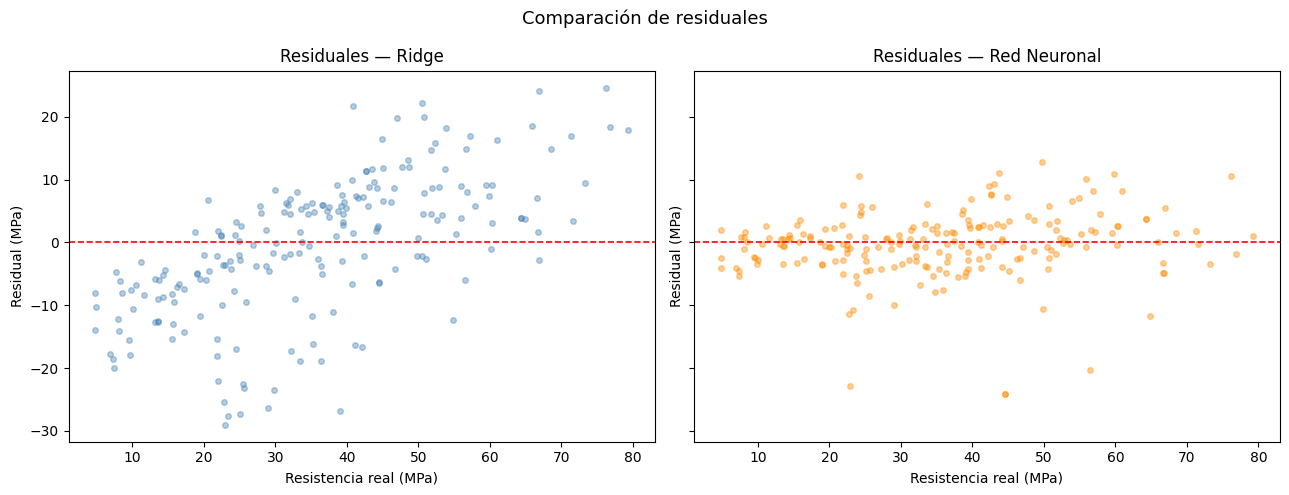

Ridge   — Media: -0.69 MPa | Std: 11.02 MPa
Red NN  — Media: -0.41 MPa | Std: 5.26 MPa


In [50]:
resid_ridge = y_true_mpa.flatten() - y_ridge_mpa.flatten()
resid_nn    = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, resid, title, color in [
    (axes[0], resid_ridge, "Residuales — Ridge",          "steelblue"),
    (axes[1], resid_nn,    "Residuales — Red Neuronal",   "darkorange"),
]:
    ax.scatter(y_true_mpa, resid, alpha=0.4, s=16, color=color)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Resistencia real (MPa)")
    ax.set_ylabel("Residual (MPa)")
    ax.set_title(title)

plt.suptitle("Comparación de residuales", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Ridge   — Media: {resid_ridge.mean():.2f} MPa | Std: {resid_ridge.std():.2f} MPa")
print(f"Red NN  — Media: {resid_nn.mean():.2f} MPa | Std: {resid_nn.std():.2f} MPa")


> **Pregunta 8.2** — **Ridge:** patrón sistemático en arco, sobreestima resistencias bajas (<20 MPa) y subestima las altas (>60 MPa), firma característica de un modelo lineal ajustando una relación no lineal. **Red Neuronal:** residuales uniformemente distribuidos alrededor de 0 sin patrón sistemático, errores mucho menores en magnitud.

> **Pregunta 8.3** — La diferencia de 5.8 MPa es prácticamente significativa en ingeniería estructural. Presentaría la red neuronal validada en 206 mezclas independientes, mostrando la comparación en MPa (lenguaje del ingeniero). Para mejorar aún más: más datos (5k-10k mezclas), features de interacción derivadas y variables de proceso. Consideración ética: un modelo de caja negra en diseño estructural no es auditable, ya que si la predicción falla, el ingeniero firmante asume la responsabilidad legal sin poder justificar la decisión del modelo.

---
## Parte 9: Reflexión

> **Pregunta 9.1** — `loss.backward()` aplica la regla de la cadena hacia atrás por el grafo computacional: calcula $\partial L/\partial w_i$ para cada parámetro. Para $W_1$ de `ConcreteNet`: $\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial a_2} \cdot \frac{\partial a_2}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1}$. El gradiente resultante indica cuánto cambiar cada peso para reducir el MSE.

> **Pregunta 9.2** — Tres razones por las que el Teorema de Aproximación Universal no garantiza RMSE ≈ 0:
> 1. El teorema dice que la red *existe*, no que el optimizador la *encuentra* con 700 muestras — el espacio de hipótesis es enorme y los datos insuficientes para cubrirlo.
> 2. Adam/SGD puede quedar atrapado en mínimos locales o puntos de silla de una función no convexa de 4,801 variables.
> 3. El ruido irreducible de los datos (variación en pruebas de compresión, lotes de cemento distintos, variables no medidas) impone un piso al RMSE que no se puede eliminar.

> **Pregunta 9.3** — Puede ocurrir `val < train` con: **Dropout alto en train**: la red usa menos neuronas en train, produciendo pérdida artificialmente mayor que en eval. **val set más fácil por azar**: con 124 muestras puede haber menos outliers que en los 700 de train. **batch size pequeño**: batches de 8 tienen alta varianza, con picos que elevan el promedio del train loss.

> **Pregunta 9.4** — Con **datos tabulares de 1k muestras**, las redes no tienen ventaja clara sobre modelos lineales bien regularizados. Se justifican claramente cuando hay datos de imagen/texto (CNNs/Transformers), decenas de miles de muestras, o relaciones de alta dimensión que requieren representaciones jerárquicas.

> **Pregunta 9.5** — El momento más claro fue entender `zero_grad()`: en PyTorch los gradientes son **propiedades persistentes** de los tensores que se acumulan hasta limpiarse explícitamente. El orden de las 5 líneas del training loop no es una receta — es una secuencia con lógica propia donde `zero_grad()` determina exactamente qué gradiente se usa para la actualización.

---
## Resumen final de resultados

| Métrica | Valor |
|---|---|
| **Dataset** | 1,030 muestras × 8 features |
| **Split** | Train: 700 / Val: 124 / Test: 206 |
| **Modelo base** | ConcreteNet (2×64) — 4,801 parámetros |
| **RMSE Red Neuronal base** | **5.22 MPa** |
| **MAE Red Neuronal base** | **3.61 MPa** |
| **RMSE Ridge** | 11.04 MPa |
| **Mejor arquitectura** | Wide (2×256) (RMSE = 4.89 MPa) |
| **Mejor batch size** | 8 (RMSE = 4.82 MPa) |
| **Mejor learning rate** | 1e-2 (Val Loss = 0.0797) |
| **Mejor dropout** | 0.1 (RMSE = 5.20 MPa) |
| **Early stopping** | Epoch 119 de 300 |
